# Lecture 07 - Exercise: Irreducible Mass (Kernel Density Estimation)

In [207]:
#######################
### L07 - Exercises ###
#######################

In [208]:
# importing libraries and setting up nice plots

import os
import numpy                        as     np
import matplotlib.pyplot            as     plt
from   matplotlib                   import rc
from   sys                          import stdout
from   scipy                        import stats, integrate
from   astroML                      import stats as astroMLstats
from   astropy.visualization.hist   import hist as fancyhist
from   sklearn.neighbors            import KernelDensity


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

# did we start this notebook from ".../GitHub/working" directory or from ".../GitHub" (by accident)?
current_pwd = os.getcwd()
print(current_pwd)

D:\Documents\University\Magistrale\Statistics\GitHub\working


# Tasks 1, 2, 3:

In [209]:
#------------------------------------------------------------------------------------------------
# definining the distributions for the "measured" Black Holes variables, and the irreducible mass
#------------------------------------------------------------------------------------------------

# number of Black Hole "measurements":
N = 10000

# BH masses are distributed NORMALLY:
mu_M = 1.
sigma_M = 0.02
distr_M = stats.norm(mu_M,sigma_M)

# BH spins are distributed UNIFORMLY in (0,1):
distr_chi = stats.uniform(0,1)

# the Irreducible Mass as a function of Mass and Spin:
def irreducible_mass(M,chi):
    return M * np.sqrt( ( 1 + np.sqrt(1 - chi**2) ) / 2 )

#-------------------------------------------------------------------------------------------
# just defining a quicker way to call the Kernel Density Estimator

def KDE_sklearn(data, bandwidth=1.0, kernel="epanechnikov", size=N):
    xgrid = np.linspace( data.min(), data.max(), size)
    # here is the actual KDE definition and computation
    kde_skl = KernelDensity(bandwidth=bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    # apply the KDE to the xgrid and return it
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) 
    return np.exp(log_pdf) , xgrid # because sklearn returns log(density)

#-------------------------------------------------------------------------------------------

In [210]:
#-------------------------------------------------------------------------------------------
# extracting the "measurements" for mass and spin, then computing irreducible mass with them
#-------------------------------------------------------------------------------------------

M = distr_M.rvs(N)               # or   M = np.random.normal(loc=mu_M, scale=sigma_M, size=N)
chi = distr_chi.rvs(N)           # or chi = np.random.uniform(size=N)
M_irr = irreducible_mass(M,chi)

#-------------------------------------------------------------------------------------------

In [211]:
#-------------------------------------------------------------------------------------------
# quick preliminary analysis for histograms and KDEs

# quantiles
q     = [0.25, 0.50, 0.75]
q_chi = np.quantile(chi, q)
q_M   = np.quantile(M, q)
q_irr = np.quantile(M_irr, q)

print("25%, 50%, 75% quantiles, Spin:  {:.5f} ; {:.5f} ; {:.5f}".format(q_chi[0],q_chi[1],q_chi[2]))
print("25%, 50%, 75% quantiles, Mass:  {:.5f} ; {:.5f} ; {:.5f}".format(q_M  [0],q_M  [1],q_M  [2]))
print("25%, 50%, 75% quantiles, Mirr:  {:.5f} ; {:.5f} ; {:.5f}".format(q_irr[0],q_irr[1],q_irr[2]))

#-------------------------------------------------------------------------------------------

25%, 50%, 75% quantiles, Spin:  0.24821 ; 0.50301 ; 0.75005
25%, 50%, 75% quantiles, Mass:  0.98647 ; 1.00017 ; 1.01381
25%, 50%, 75% quantiles, Mirr:  0.90909 ; 0.96153 ; 0.98986


binsize, scott rule: 0.01043
binsize, freedman-diaconis rule: 0.00750 or equiv. 0.00750


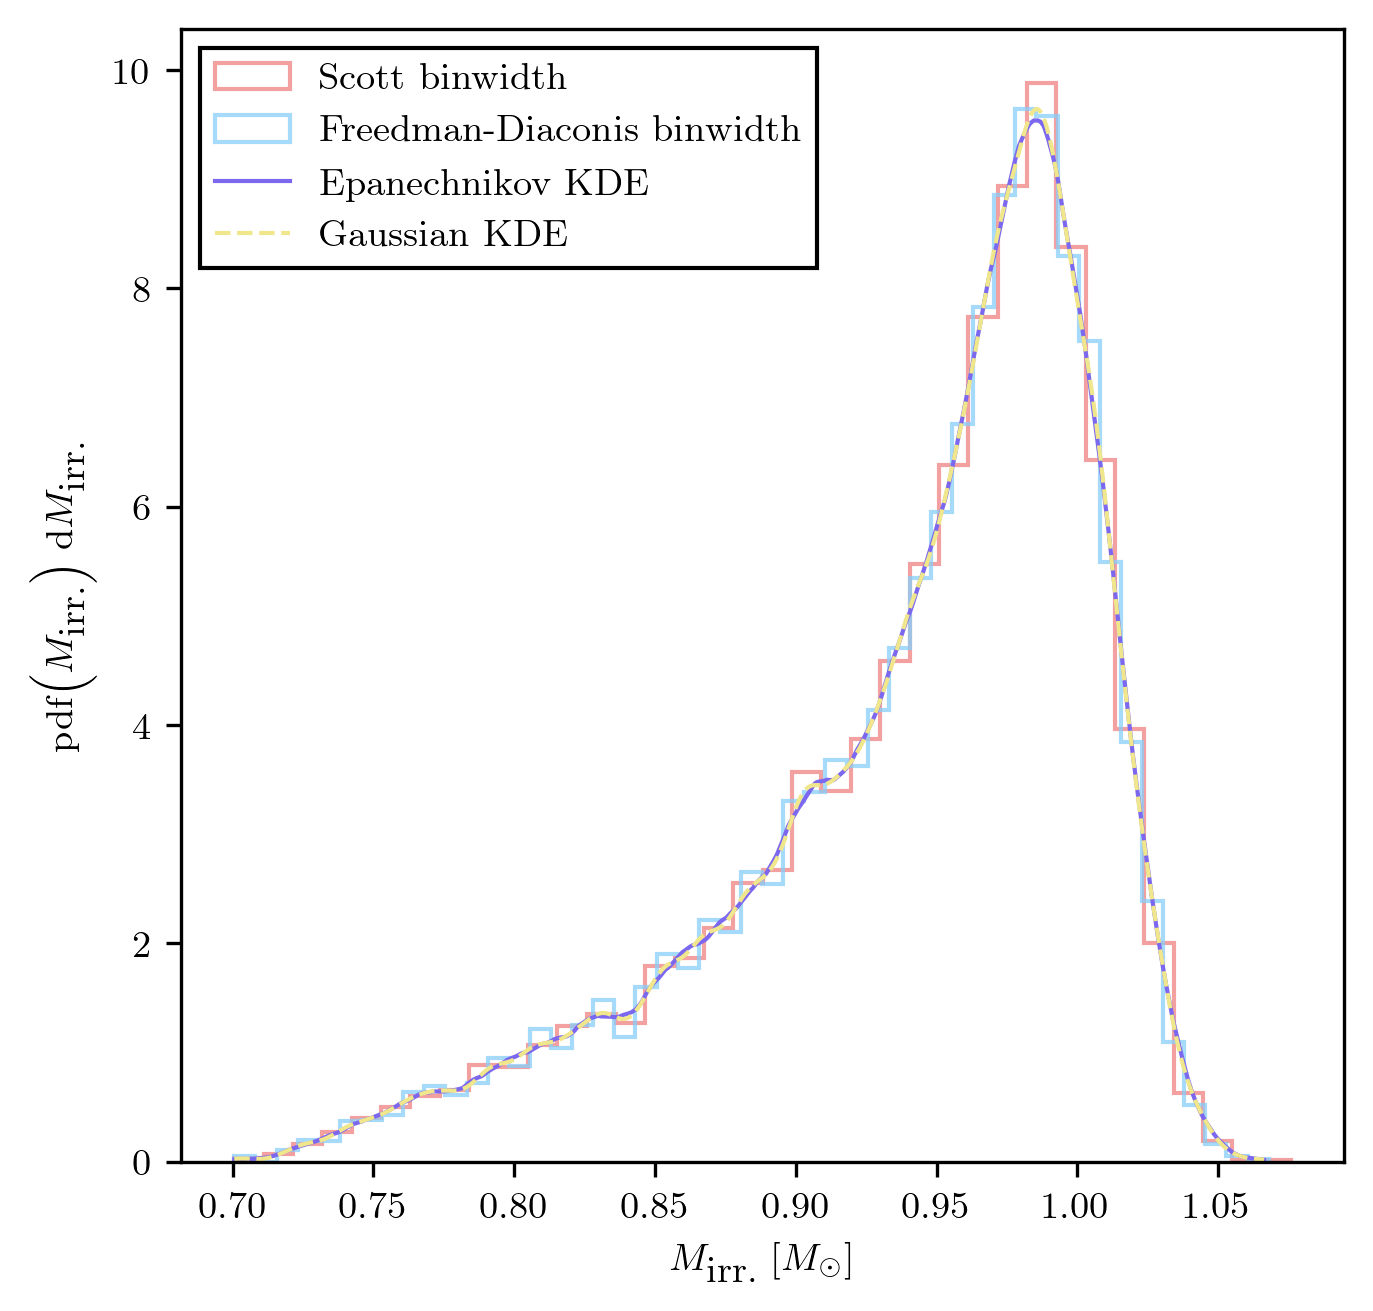

In [212]:
#-------------------------------------------------------------------------------------------
# Histograms for the irreducible mass, and first KDEs 
#-------------------------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(5,5))

ax.set_xlabel(r"$M_{\textup{irr.}} \; [ M_\odot ]$")
ax.set_ylabel(r"$ \textup{pdf}\big( M_{\textup{irr.}} \big) \; \textup{d}M_{\textup{irr.}} $")
# ax.set_ylabel(r"$ { \displaystyle \frac{ \textup{d}N }{ \textup{d} M_{\textup{irr.}} } } $", rotation='horizontal', labelpad=15)

#-------------------------------------------------------------------------------------------
# histogram with Scott rule for bins: 
## bin_width = 3.5 std_dev / cube_root(N)

binsize_scott = 3.5 * np.std(M_irr, ddof=1) / np.cbrt(N)
print("binsize, scott rule: {:.5f}".format(binsize_scott))

_ = fancyhist(M_irr, bins="scott", histtype="step",density=True, alpha=0.75, color='lightcoral', label='Scott binwidth')

#-------------------------------------------------------------------------------------------
# histogram with Freedman-Diaconis rule for bins: 
## bin_width = 2 (q_75 - q_25) / cube_root(N) = 2.7 sigma_G / cube_root(N)

binsize_freedman_1 = 2.7 * astroMLstats.sigmaG(M_irr) / np.cbrt(N)
binsize_freedman_2 = 2 * ( np.quantile(M_irr,0.75) - np.quantile(M_irr,0.25)) / np.cbrt(N)
print("binsize, freedman-diaconis rule: {:.5f} or equiv. {:.5f}".format(binsize_freedman_1, binsize_freedman_2))

_ = fancyhist(M_irr, bins="freedman", histtype="step",density=True, alpha=0.75, color='lightskyblue', label='Freedman-Diaconis binwidth')

#-------------------------------------------------------------------------------------------
# KDE number 1: Epanechnikov kernel function, bandwidth estimated just by playing around numerically

PDF_epan, Mirr_KDE = KDE_sklearn(M_irr,bandwidth=0.012,kernel="epanechnikov")
ax.plot(Mirr_KDE, PDF_epan, ls='-', lw=1, color='mediumslateblue', label='Epanechnikov KDE')

#-------------------------------------------------------------------------------------------
# KDE number 1: Gaussian kernel function, bandwidth estimated just by playing around numerically

PDF_gauss , _ = KDE_sklearn(M_irr,bandwidth=0.005,kernel="gaussian")
ax.plot(Mirr_KDE, PDF_gauss, ls='--', lw=1, color='khaki', label='Gaussian KDE')

# --------------------------------------------------------------------------------------
# Utility: legend, saving the figure...

_ = ax.legend(loc=2,frameon=True, framealpha=1, fancybox=False, edgecolor='black')

# do we want to save the figure?
if True:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L07_images/L07_Mirr_Histo_and_KDE.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L07_images/L07_Mirr_Histo_and_KDE.pdf', bbox_inches='tight')


# Tasks 4, 5, 6

In [213]:
#-------------------------------------------------------------------------------------------
# extracting the "measurements" for mass and spin, then computing irreducible mass with them
# but for 100 different values of sigma = stddev of pdf(mass)
# compute for each sigma also whether the resulting sampling m_irr is more compatible
# with the mass sampling or the chi sampling (by doing two KS tests)
#-------------------------------------------------------------------------------------------

sigmas = mu_M * np.logspace(-5, 2, 1000) 
M_sigmas     = []
chi_sigmas   = []
M_irr_sigmas = []
KS_M_sigmas  = []
KS_f_sigmas  = []

for s in sigmas:
    m = np.random.normal(loc=mu_M, scale=s, size=N)
    c = np.random.uniform(size=N)
    mirr = irreducible_mass(m,c)
    f = mirr / m
    KS_m = stats.ks_2samp(mirr,m)
    KS_f = stats.ks_2samp(mirr,f)
    M_sigmas.append(m)
    chi_sigmas.append(c)
    M_irr_sigmas.append(mirr)
    KS_M_sigmas.append(KS_m.statistic)
    KS_f_sigmas.append(KS_f.statistic)

#-------------------------------------------------------------------------------------------

We can see in the following plot that the KS statistic computed between the irreducible mass and the mass decreases with $\sigma_M$, while instead the opposite trend is observed for the KS statistic computed between the irreducible mass and the $f$ parameter, which is only dependent on the spin: $f(\chi)$. 

In other words, for $\sigma_M \ll \mu_M $ we infer that $\textup{pdf}(M_\textup{irr.})$ resembles $\textup{pdf}(M) $, while instead for $\sigma_M \gg \mu_M $ we infer that $\textup{pdf}(M_\textup{irr.})$ resembles $\textup{pdf}(f) $. 

Therefore, we aim to compute $\textup{pdf}(M_\textup{irr.}) $ and verify these limits. 

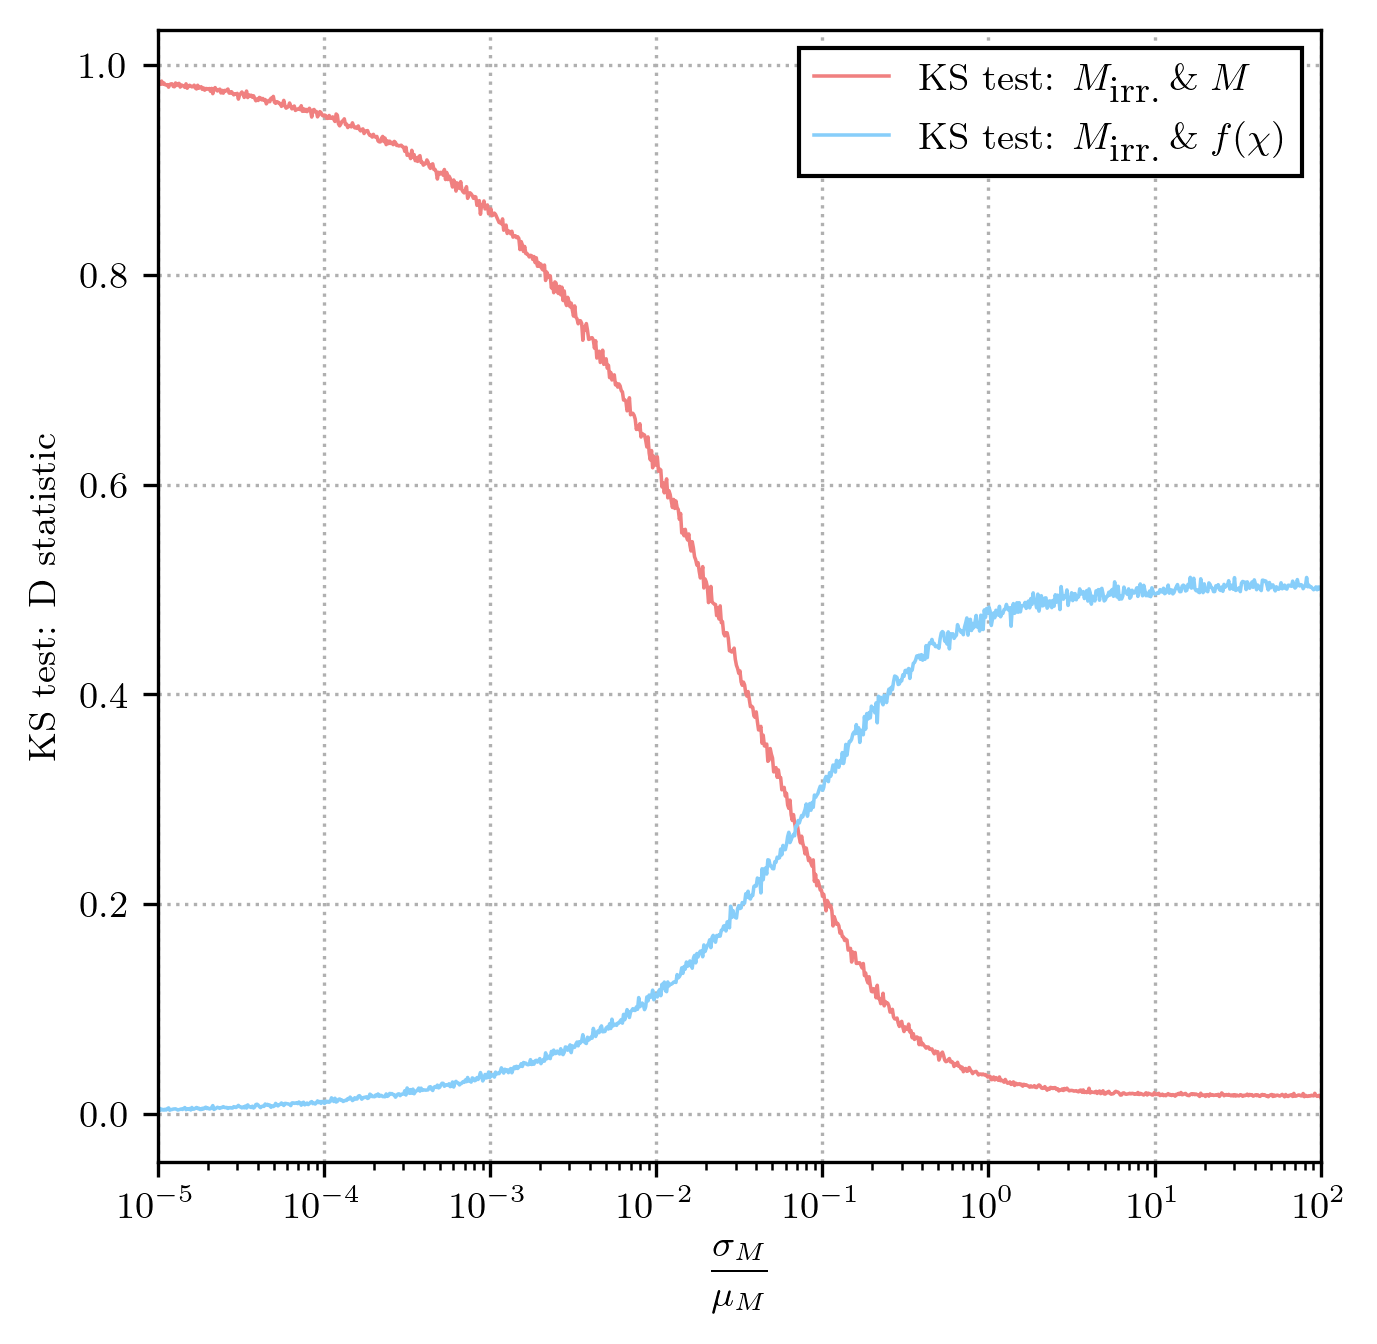

In [214]:
fig , ax = plt.subplots(figsize=(5,5))

ax.set_xlabel(r"${ \displaystyle \frac{\sigma_M}{\mu_M}}$") 
ax.set_ylabel(r"KS test: D statistic")
ax.set_xscale('log')
ax.set_xlim(1e-5,1e2)

ax.plot(sigmas / mu_M, KS_M_sigmas, label=r'KS test: $M_\textup{irr.} \,\&\; M$', color='lightcoral', lw=0.85)
ax.plot(sigmas / mu_M, KS_f_sigmas, label=r'KS test: $M_\textup{irr.} \,\&\; f(\chi)$', color='lightskyblue', lw=0.85)

ax.grid(ls=':')
_ = ax.legend(loc=1,frameon=True, framealpha=1, fancybox=False, edgecolor='black')
# do we want to save the figure?
if True:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L07_images/L07_KS_tests_Mirr_M_f.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L07_images/L07_KS_tests_Mirr_M_f.pdf', bbox_inches='tight')



# Task 7

We have an analytical model $M_\textup{irr.}=M_\textup{irr.}(M,\chi)$, so we can compute $\textup{pdf}(M_\textup{irr.})$ from $\textup{pdf}(M)$ and $\textup{pdf}(\chi)$, even if some integrals are to be evaluated numerically.



First, one can define the variable $f(\chi)$  dividing $M_{\textup{irr.}}$ by $M$; we can analytically compute its pdf with the conservation of probability:

$$ %%% \mkern-25mu & \mkern-25mu = \mkern-25mu & \mkern-25mu
\begin{array}{rcrcl}
    \phantom{0\Bigg|}
    \textup{define:}
    & \phantom{0} & 
f(\chi) 
    \!\!&\!\! = \!\!&\!\!
    \dfrac{M_\textup{irr.}}{M} 
    = \sqrt{\frac{1}{2}} \, \sqrt{1 + \sqrt{1-\chi^2}}
\\
    \phantom{0\bigg|} 
    \implies 
    & \phantom{0} & 
    2f^2 
    \!\!&\!\! = \!\!&\!\!
    1 + \sqrt{1-\chi^2}
\\
    \phantom{0\bigg|} 
    \implies 
    & \phantom{0} &
    1 - \chi^2
    \!\!&\!\! = \!\!&\!\!
    \big( 2f^2-1 \big)^2 
\\
    \phantom{0\bigg|} 
    \implies
    & \phantom{0} &
    \chi^2 
    \!\!&\!\! = \!\!&\!\!
    -4f^4 + 4f^2 -1+1 = 4f^2 \big(1 - f^2 \big)
\\
    \phantom{0\bigg|}
    \textup{we've found the inverse:}
    & \phantom{0} &
\chi(f)
    \!\!&\!\! = \!\!&\!\!
    2f\sqrt{1-f^2}
\\
    \phantom{0\bigg|}
    \textup{and its derivative:}
    & \phantom{0} &
\dfrac{\textup{d}\chi}{\textup{d}f}
    \!\!&\!\! = \!\!&\!\!
    2\sqrt{1-f^2} + 2f \dfrac{-2f}{ 2\sqrt{1-f^2} }
    = \dfrac{ 2(1-f^2) - 2f^2}{ \sqrt{1-f^2} }
    = \dfrac{ 2(1-2f^2)}{ \sqrt{1-f^2} }
\\ \\
    \phantom{0\Bigg|^|}
    \textup{the original pdf was:}
    & \phantom{0} &
\textup{pdf}(\chi)
    \!\!&\!\! = \!\!&\!\!
    \textup{Uniform}(0,1) 
    = \left\{ 
        \begin{array}{lll} 
        1 & \textup{ if } & 0 \leq \chi \leq 1 
        \\
        0 & \textup{ if } & \chi < 0 \vee \chi > 1 
        \end{array} 
    \right.
\\ \\
    \phantom{0\Bigg|}
    \textup{note the monotony of } f(\chi):
    & \phantom{0} &
\dfrac{\textup{d}f}{\textup{d}\chi}
    \!\!&\!\! = \!\!&\!\!
    \dfrac{1}{\sqrt{2}} \,\dfrac{\textup{d}}{\textup{d}\chi} \sqrt{1+\sqrt{1-\chi^2}}
    = \dfrac{1}{2\sqrt{2}} \dfrac{1}{\sqrt{1+\sqrt{1-\chi^2}}} \dfrac{\textup{d}}{\textup{d}\chi} \sqrt{1-\chi^2}
    = \dfrac{1}{2\sqrt{2}} \dfrac{1}{\sqrt{1+\sqrt{1-\chi^2}}} \dfrac{-2\chi}{ 2\sqrt{1-\chi^2}} 
\\ \\
    \phantom{0\Bigg|}
    \implies
    & \phantom{0} & 
\dfrac{\textup{d}f}{\textup{d}\chi}
    \!\!&\!\! \leq \!\!&\!\!
    0 \quad \forall\; \chi \geq 0
    \implies 
    \left\{ 
        \begin{array}{l} 
        \textup{max}(f) = f(\chi=0) = 1
        \\
        \textup{min}(f) = f(\chi=1) = \sqrt{\dfrac{1}{2}}
        \end{array} 
    \right.
\\ \\
    \phantom{0\bigg|}
    \textup{use probability conservation:}
    & \phantom{0} &
\textup{pdf}(\chi) \, \textup{d}\chi 
    \!\!&\!\! = \!\!&\!\!
    \textup{pdf}\big(\chi(f)\big) \, \Big|\dfrac{\textup{d}\chi}{\textup{d}f}\Big| \, \textup{d}f
    = \textup{pdf}(f) \, \textup{d}f  
    % \textup{pdf}\big(f(\chi)\big) \, \dfrac{\textup{d}f}{\textup{d}\chi} \, \textup{d}\chi 
\\ \\
    \phantom{0\bigg|}
    \textup{to finally compute:}
    & \phantom{0} &
\textup{pdf}(f) 
    \!\!&\!\! = \!\!&\!\!
    \left\{ 
        \begin{array}{cl} 
        \dfrac{ 2(2f^2 -1)}{ \sqrt{1-f^2} } & \textup{if} \quad \sqrt{\dfrac{1}{2}} \leq f < 1 
        \\
        0 & \textup{elsewhere }
        \end{array} 
    \right.
\end{array}
$$



Let us go on with the computation. Let us manipulate the relations between $M_\textup{irr.}, M, \chi, f$:

$
M_\textup{irr.}(M,\chi)
= M \cdot f(\chi)
\quad \implies \quad
M(M_\textup{irr.},f)
= \dfrac{M_\textup{irr.}}{f}
$

We have just computed $\textup{pdf}(f)$; but also $\textup{pdf}(M)$ is known, a normal distribution. We can rewrite it as a conditional $\textup{pdf}(M_{\textup{irr.}}|f)$ to obtain the marginal $\textup{pdf}(M_\textup{irr.})$ via Bayes'theorem.

$
\textup{pdf}(M)  \textup{d}M 
= \mathcal{N}(\mu_M,\sigma_M) \,\textup{d}M =
$

$ \phantom{\textup{pdf}(M)\textup{d}M}
= \dfrac{1}{\sigma_M\sqrt{2\pi}} \exp\!\Bigg( \!-\!\dfrac{1}{2}\bigg( \dfrac{\mu_M-M}{\sigma_M} \bigg)^2 \Bigg) \, \textup{d}M =
$

$ \phantom{\textup{pdf}(M)\textup{d}M}
= \dfrac{1}{\sigma_M\sqrt{2\pi}} \exp\!\Bigg( \!-\!\dfrac{1}{2}\bigg( \dfrac{\mu_M-M_\textup{irr.}/f}{\sigma_M} \bigg)^2 \Bigg) 
\, \dfrac{\textup{d}M}{\textup{d}M_\textup{irr.}} \textup{d}M_\textup{irr.} = 
$

$ \phantom{\textup{pdf}(M)\textup{d}M}
= \dfrac{1}{\sigma_M\sqrt{2\pi}} \exp\!\Bigg( \!-\!\dfrac{1}{2}\bigg( \dfrac{\mu_M-M_\textup{irr.}/f}{\sigma_M} \bigg)^2 \Bigg) 
\, \dfrac{1}{f} \; \textup{d}M_\textup{irr.}
= \textup{pdf}(M_\textup{irr.} | f) \; \textup{d}M_\textup{irr.}
$

With the conditional  $\textup{pdf}(M_\textup{irr.} | f)$  we can just use Bayes' theorem since the marginal $\textup{pdf}(f)$ is known:

$$
\textup{pdf}\big( M_\textup{irr.}\big) 
= \int_{-\infty}^{+\infty}                      %\int_{f_\textup{min}}^{f_\textup{max}} 
\; \textup{pdf}\big( M_\textup{irr.} | f \big) 
\; \textup{pdf}(f) 
\; \textup{d}f 
= {\displaystyle \int_{\sqrt{\frac{1}{2}}}^1 } 
\, \dfrac{ 1 }{\sigma_M \, \sqrt{2\pi}} 
\, \exp\Bigg(\!\!-\!\dfrac{1}{2} \bigg( \dfrac{\mu_M - M_\textup{irr.} / f }{\sigma_M} \bigg)^2 \Bigg)
\, \dfrac{1}{f} 
\, \dfrac{ 2(2f^2-1)}{ \sqrt{1-f^2} } 
\, \textup{d}f .
$$

Or rather, our inner mathematician can cry, since this integral looks angry... we have to resort to dirty ol' numerical computation :)


In [215]:
#-------------------------------------------------------------------------
# define the integrand step by step, then the pdf
#-------------------------------------------------------------------------

#-------------------------------------------------------------------------
# pdf(f) # the marginal in f(chi)

def pdf_f(f):
    return 2 * np.abs( (1 - 2* f**2) ) / np.sqrt( 1 - f**2 )

#------------------------------------------------------------------------
# pdf(M) # the marginal in M

def pdf_M(M,m=mu_M,s=sigma_M):
    vars = (m - M) / s
    norm = 1 / (s * np.sqrt(2*np.pi) )
    return norm * np.exp(-0.5* vars**2)

#-------------------------------------------------------------------------
# the derivative of pdf(M_irr), which we must integrate in df

def pdf_M_irr__integrand( f, M_irr, m=mu_M, s=sigma_M):
    jac = 1/f
    conditional_pdf_M_on_f = pdf_M( M_irr/f, m, s ) * jac
    marginal_pdf_f = pdf_f(f)
    return  conditional_pdf_M_on_f * marginal_pdf_f

#-------------------------------------------------------------------------
# pdf(M_irr) # obtained with numerical integration 
# note: "scipy.integrate.quad" numerically integrates
#       the function "pdf_M_irr__integrand(f,M_irr)"
#       in "f", while we pass "M_irr" as a parameter: "args=(M_irr,)"

def pdf_M_irr(var_Mirr, m=mu_M, s=sigma_M, var_min=1./np.sqrt(2), var_max=1.):
    return integrate.quad( pdf_M_irr__integrand, var_min, var_max, args=(var_Mirr,m,s,))[0]

#-------------------------------------------------------------------------

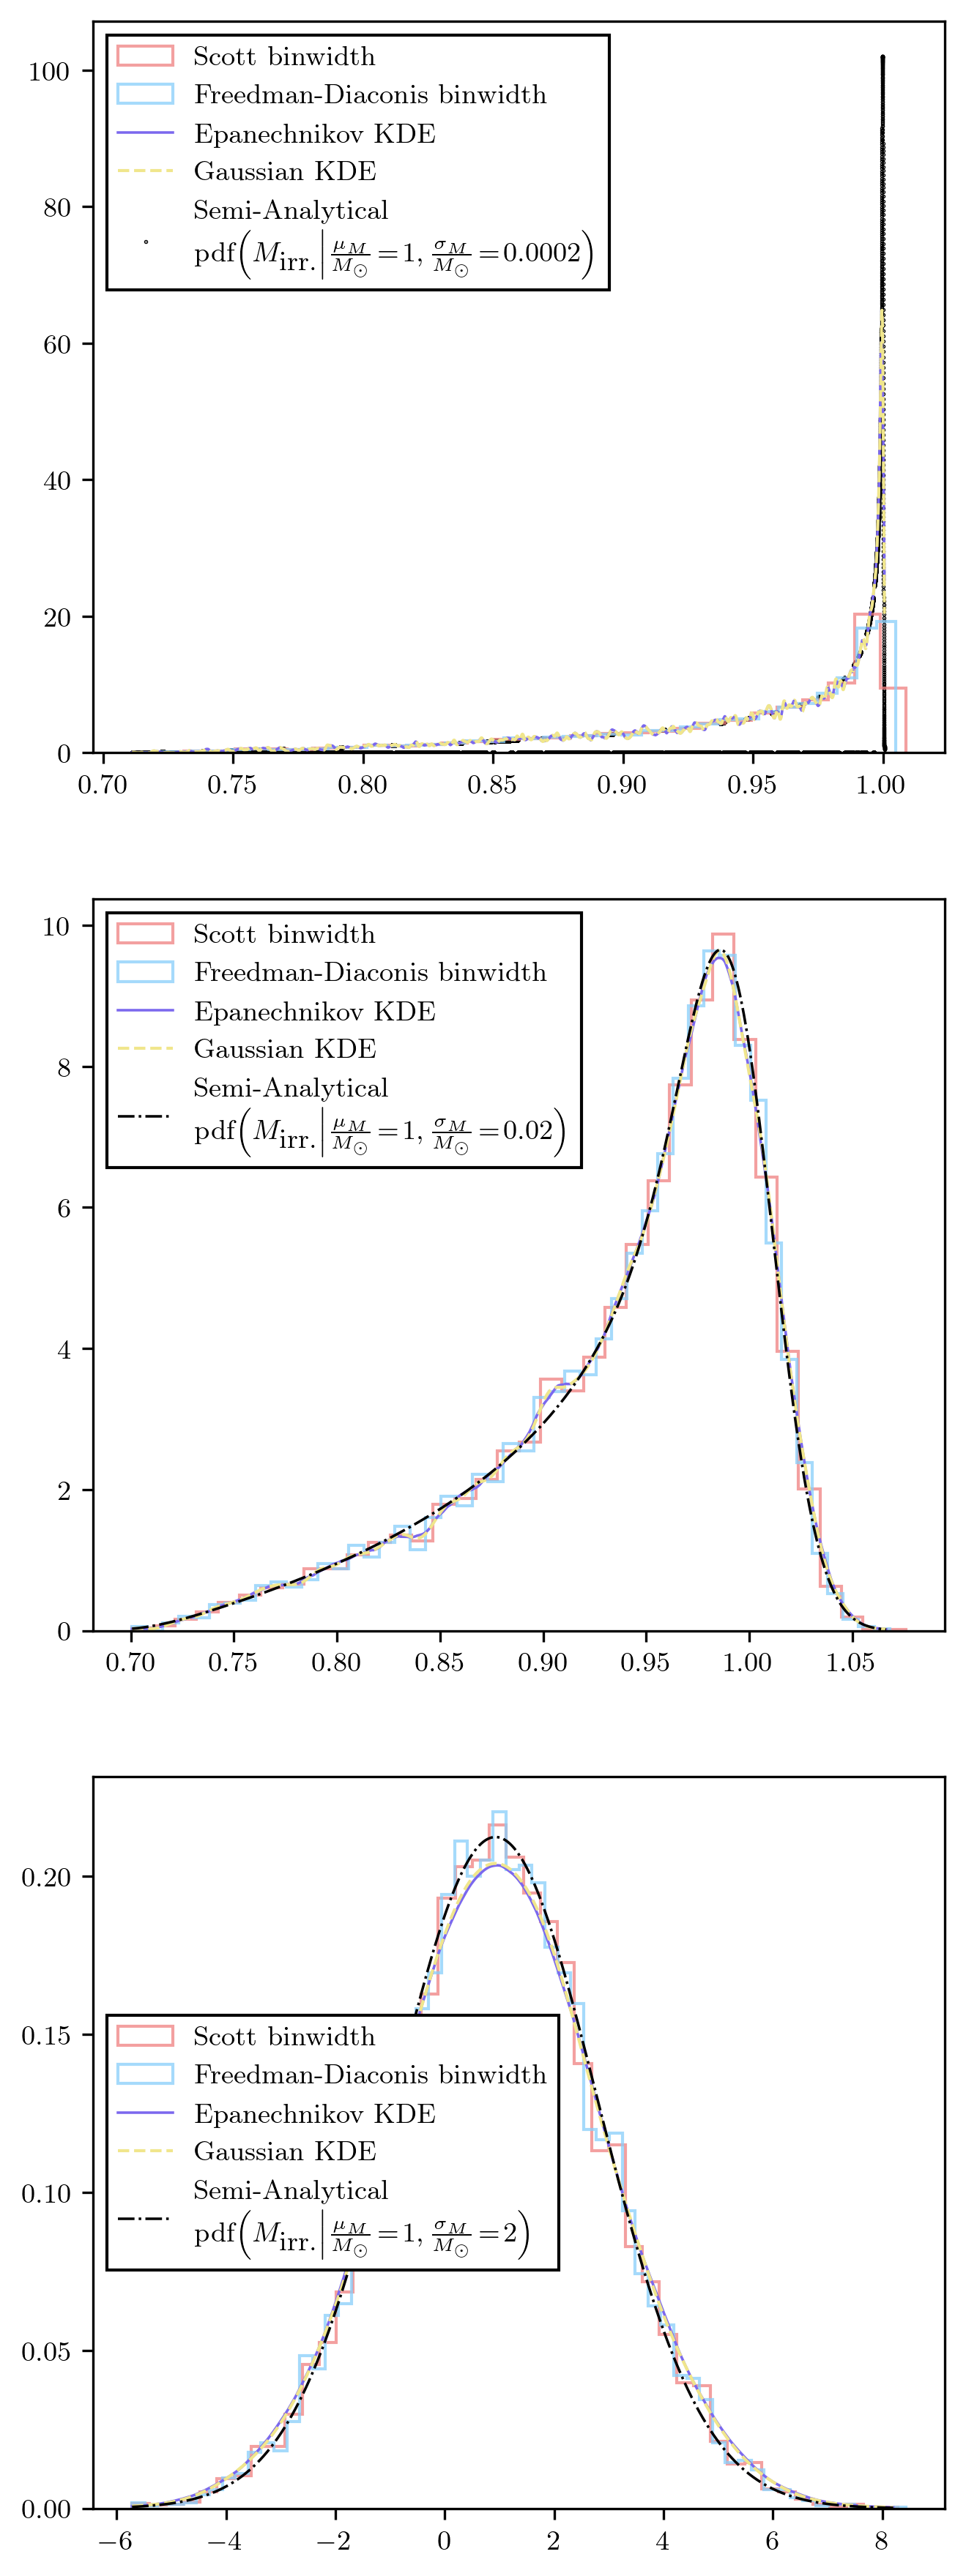

In [225]:
#-------------------------------------------------------------------------
# plot the semi-analytical pdf and compare it to the previous histograms and KDEs
# for different values of sigma_M
#-------------------------------------------------------------------------

fig , ax = plt.subplots(3,1, figsize=(5,15))

sigma_small = 0.0002
sigma_large = 2.

M_small = np.random.normal(loc=mu_M, scale=sigma_small, size=N)
M_large = np.random.normal(loc=mu_M, scale=sigma_large, size=N)

c_small = np.random.uniform(size=N)
c_large = np.random.uniform(size=N)

Mirr_small = irreducible_mass(M_small,c_small)
Mirr_large = irreducible_mass(M_large,c_large)

KS_m_small = stats.ks_2samp(Mirr_small,M_small).statistic
KS_m_small = stats.ks_2samp(Mirr_large,M_large).statistic
KS_c_small = stats.ks_2samp(Mirr_small,c_small).statistic
KS_c_small = stats.ks_2samp(Mirr_large,c_large).statistic

PDF_small_epan  , Mirr_small_KDE = KDE_sklearn(Mirr_small, bandwidth=0.012/10, kernel="epanechnikov")
PDF_large_epan  , Mirr_large_KDE = KDE_sklearn(Mirr_large, bandwidth=0.012*100, kernel="epanechnikov")
PDF_small_gauss , _ = KDE_sklearn(Mirr_small, bandwidth=0.005/10, kernel="gaussian")
PDF_large_gauss , _ = KDE_sklearn(Mirr_large, bandwidth=0.005*100, kernel="gaussian")

Mirr_theory = np.copy(Mirr_KDE)
PDF_theory = np.zeros_like(Mirr_theory)
for i, m in enumerate(Mirr_theory):
    PDF_theory[i] = pdf_M_irr(m)

Mirr_small_theory = np.linspace(Mirr_small.min(),Mirr_small.max(),N*10)
# np.logspace(np.log10(Mirr_small.min()), np.log10(Mirr_small.max()), int(N*10))
PDF_small_theory = np.zeros_like(Mirr_small_theory)
for i, ms in enumerate(Mirr_small_theory):
    PDF_small_theory[i] = pdf_M_irr(ms,m=mu_M,s=sigma_small)

Mirr_large_theory = np.linspace(Mirr_large.min(), Mirr_large.max(),N)
PDF_large_theory = np.zeros_like(Mirr_large_theory)
for i, ml in enumerate(Mirr_large_theory):
    PDF_large_theory[i] = pdf_M_irr(ml,m=mu_M,s=sigma_large)

label_pdf = 'Semi-Analytical\n'+ r'$ \textup{pdf}\big( M_\textup{irr.} \big| \frac{\mu_M}{M_\odot}\!=\!1, \frac{\sigma_M}{M_\odot}\!=\!0.02 \big) $ '
label_pdf_small = 'Semi-Analytical\n'+ r'$ \textup{pdf}\big( M_\textup{irr.} \big| \frac{\mu_M}{M_\odot}\!=\!1, \frac{\sigma_M}{M_\odot}\!=\!0.0002 \big) $ '
label_pdf_large = 'Semi-Analytical\n'+ r'$ \textup{pdf}\big( M_\textup{irr.} \big| \frac{\mu_M}{M_\odot}\!=\!1, \frac{\sigma_M}{M_\odot}\!=\!2 \big) $ '

# the histograms (previous results + new histograms for large and small sigma)
_ = fancyhist(M_irr, ax=ax[1], bins="scott", histtype="step",density=True, alpha=0.75, color='lightcoral', label='Scott binwidth')
_ = fancyhist(M_irr, ax=ax[1], bins="freedman", histtype="step",density=True, alpha=0.75, color='lightskyblue', label='Freedman-Diaconis binwidth')
_ = fancyhist(Mirr_small, ax=ax[0], bins="scott", histtype="step",density=True, alpha=0.75, color='lightcoral', label='Scott binwidth')
_ = fancyhist(Mirr_small, ax=ax[0], bins="freedman", histtype="step",density=True, alpha=0.75, color='lightskyblue', label='Freedman-Diaconis binwidth')
_ = fancyhist(Mirr_large, ax=ax[2], bins="scott", histtype="step",density=True, alpha=0.75, color='lightcoral', label='Scott binwidth')
_ = fancyhist(Mirr_large, ax=ax[2], bins="freedman", histtype="step",density=True, alpha=0.75, color='lightskyblue', label='Freedman-Diaconis binwidth')

# the KDEs (previous results + new KDEs for large and small sigma)
ax[1].plot(Mirr_KDE, PDF_epan, ls='-', lw=0.85, color='mediumslateblue', label='Epanechnikov KDE')
ax[1].plot(Mirr_KDE, PDF_gauss, ls='--', lw=1, color='khaki', label='Gaussian KDE')
ax[0].plot(Mirr_small_KDE, PDF_small_epan, ls='-', lw=0.85, color='mediumslateblue', label='Epanechnikov KDE')
ax[0].plot(Mirr_small_KDE, PDF_small_gauss, ls='--', lw=1, color='khaki', label='Gaussian KDE')
ax[2].plot(Mirr_large_KDE, PDF_large_epan, ls='-', lw=0.85, color='mediumslateblue', label='Epanechnikov KDE')
ax[2].plot(Mirr_large_KDE, PDF_large_gauss, ls='--', lw=1, color='khaki', label='Gaussian KDE')

# Finally, the pdf we have computed semi-analytically 
ax[1].plot(Mirr_theory, PDF_theory, color='black', ls='-.', lw=0.85, label=label_pdf)
ax[0].scatter(Mirr_small_theory, PDF_small_theory, color='black', s=0.1, label=label_pdf_small)
ax[2].plot(Mirr_large_theory, PDF_large_theory, color='black', ls='-.', lw=0.85, label=label_pdf_large)

_ = ax[1].legend(loc=2,frameon=True, framealpha=1, fancybox=False, edgecolor='black')
_ = ax[0].legend(loc=2,frameon=True, framealpha=1, fancybox=False, edgecolor='black')
_ = ax[2].legend(loc=6,frameon=True, framealpha=1, fancybox=False, edgecolor='black')

#-------------------------------------------------------------------------
# do we want to save the figure?
if True:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L07_images/L07_Mirr_Histo_and_KDE_and_Semi-analytical.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L07_images/L07_Mirr_Histo_and_KDE_and_Semi-analytical.pdf', bbox_inches='tight')

# title_pdf =  r'$ \textup{pdf}(M_\textup{irr.}) = '
# title_pdf += r'{\displaystyle \int_{\sqrt{\frac{1}{2}}}^1 } '
# title_pdf += r'\, {\displaystyle \frac{ 1 }{\sqrt{2\pi}\sigma_M} }'
# title_pdf += r'\, {\displaystyle \exp\Bigg(\!\!-\!\frac{1}{2} \bigg( \frac{\mu_M - M_\textup{irr.} / f }{\sigma_M} \bigg)^2 \Bigg) } '
# title_pdf += r'\, {\displaystyle \frac{ 2(2f^2-1)}{ \sqrt{1-f^2} } }'
# title_pdf += r'\, {\displaystyle \frac{\textup{d}f}{f}} $' 
# ax.set_title(title_pdf)